# data analysis comparison S3, ASTER08 and CCI surface temperatures
This script brings together the lake water/land surface temperature estimates above lake number 6, as derived from ASTEr08 004, Sentinel 3 LST L2 product and the CCI global lake dataset.  

In [669]:
# import modules
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely as shp
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import cartopy

In [670]:
# load lake shoreline 
lake = gpd.read_file(r'..\lake_polygons\lake_6_shoreline_shp\lake_shoreline.shp')

# the Sentinel S3 LST L2 data
S3 = pd.read_csv(r"C:\Users\Lenovo\Documents\GEUS_internship\LWST_estimation_project\Sentinel_3_LST\S3_LST_L2_lake6.csv")
S3['datetime'] = pd.to_datetime(S3['datetime'])
S3

# the ASTEr data
ASTER08 = pd.read_csv(r'C:\Users\Lenovo\Documents\GEUS_internship\LWST_estimation_project\ASTER08_LSWT\ASTER08_LST_lake_6.csv')
ASTER08['datetime'] = pd.to_datetime(ASTER08["datetime"])

# the CCI lake dataset
CCI = pd.read_csv(r"C:\Users\Lenovo\Documents\GEUS_internship\LWST_estimation_project\Copernicus_cci_LSWT_dataset\CCI_LWST_lake6.csv")
CCI['datetime'] = pd.to_datetime(CCI["datetime"])

# the landsat data and set dtypes
LS = pd.read_csv("../Landsat4-9/ST_Kangaarsuup_Tasersua.csv", dtype = 
{'LS_ST_max': 'float64', 
'LS_ST_min': 'float64', 
'LS_ST_': 'float64', 
'LS_ST_stddev': 'float64', 
'LS_ST_count': 'int64'
})
LS['date'] = pd.to_datetime(LS.date) # convert alreday given date
LS["datetime"] = pd.to_datetime(LS["system:time_start"],unit="ms") # convert from ns date


In [671]:
# add dataset name to each column to keep track wich col is which after merging
# Add "S3" to all columns except datetime
S3 = S3.rename(columns={
    col: f"S3_{col}" for col in S3.columns if col != "datetime"
})

ASTER08 = ASTER08.rename(columns={
    col: f"ASTER08_{col}" for col in ASTER08.columns if col != "datetime"
})

# Add "S3" to all columns except datetime
CCI = CCI.rename(columns={
    col: f"CCI{col}" for col in CCI.columns if col != "datetime"
})

# add LS to all columns 
LS = LS.rename(columns={
    col: f"LS_{col}" for col in LS.columns if col != "datetime"
})



In [672]:
#calculate the reliability of the estimate using the number of pixels compared to the max number of pixels
# this can then be used for a threshold the later for quality filtering

# for S3
S3["S3_frac_from_max_pixel_count"] = (S3.S3_n_valid_pixels/S3.S3_n_valid_pixels.max())


# for CCI
CCI["CCI_frac_from_max_pixel_count"] = (CCI.CCIn_valid_pixels/CCI.CCIn_valid_pixels.max())

#landsat: take away the brackets first, then convert str to int, then make calculation
LS["LS_ST_count"] = (
    LS["LS_ST_count"].str.replace("[", "", regex=False).str.replace("]", "", regex=False).str.strip())
LS['LS_ST_count'] = LS['LS_ST_count'].astype(int)
LS['LS_frac_from_max_pixel_count'] = (LS['LS_ST_count']/LS["LS_ST_count"].max())

# for ASTER08
ASTER08['ASTER08_frac_from_max_pixel_count'] = (ASTER08['ASTER08_n_valid_pixels']/ASTER08['ASTER08_n_valid_pixels'].max())


### merge all data into one dataframe for initial plotting:
Finally, using the datetime object to merge them, this is an outer join, retaining all data.
However, note that the CCi lake surface waster temperature is only daily values, and I have set the time to 12 midday. 


In [673]:
# merge all data into one df for initial plotting
combined = ASTER08.merge(
    S3,
    on="datetime",
    how="outer"
).merge(
    CCI,
    on="datetime",
    how="outer"
).merge(
   LS, on = "datetime", how = "outer" 
)

combined = combined.sort_values("datetime").reset_index(drop=True)
#combined.datetime[combined.CCIlst_mean_C.notna()] # check the time for CCI lake dataset

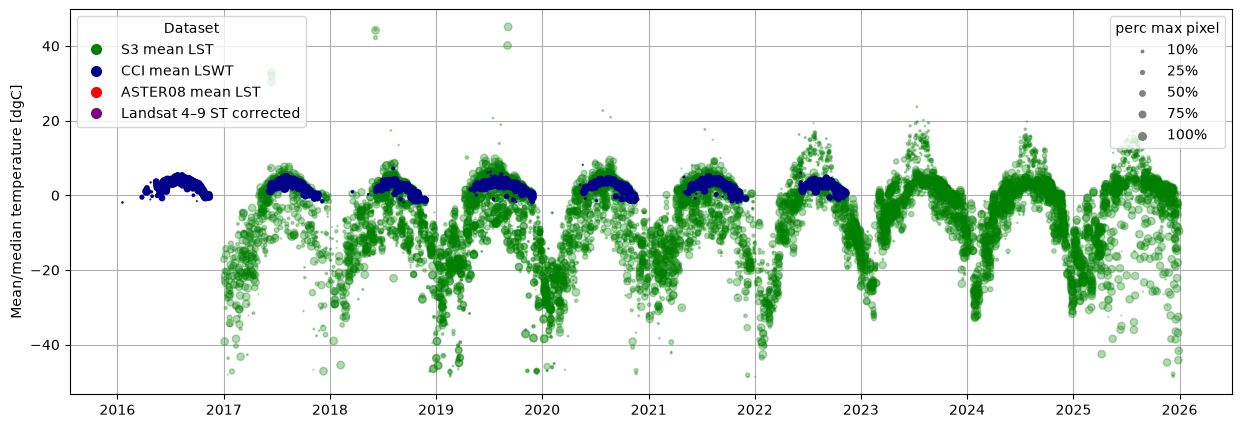

In [674]:
# make an initial plot with all data, raw as it is (quite different processing / data cleaning degrees too)
fig, ax = plt.subplots(figsize=(15, 5))

ax.set_axisbelow(True)
ax.grid(True)


#S3 first
ax.scatter(
    x = combined['datetime'], 
    y = combined.S3_lst_mean_C,
    s = combined.S3_frac_from_max_pixel_count*30, 
    marker = "o",
    alpha = 0.3, 
    color = 'green',
    label = "S3 mean LST"
)

#cci lake dataset
ax.scatter(
    x = combined['datetime'], 
    y = combined.CCIlst_median_C,
    s = combined.CCI_frac_from_max_pixel_count*30,
    marker = "o",
    color = 'darkblue',
    label = "CCI mean LSWT"
)

#ASTER08
#ax.scatter(
#    x = combined['datetime'], 
#    y = combined['ASTER08_lst_median_C'],
##    s = combined.ASTER08_frac_from_max_pixel_count*15, 
#     marker = "o",
#    color = 'red',
#    label = "ASTER08 mean LST"
#)

#Landsat4-9
#ax.scatter(
#    x = combined['datetime'], 
#    y = combined['LS_ST'],
##    s = combined.LS_frac_from_max_pixel_count*15,
#    marker = "o",
#    color = 'purple',
#    label = "mean Landsat 4-9 ST corrected"
#)

#plt.legend()
plt.ylabel('Mean/median temperature [dgC]')

from matplotlib.lines import Line2D

# Dataset legend
dataset_handles = [
    Line2D([], [], marker='o', linestyle='None',
           color='green', markersize=7, label='S3 mean LST'),
    Line2D([], [], marker='o', linestyle='None',
           color='darkblue', markersize=7, label='CCI mean LSWT'),
    Line2D([], [], marker='o', linestyle='None',
           color='red', markersize=7, label='ASTER08 mean LST'),
    Line2D([], [], marker='o', linestyle='None',
           color='purple', markersize=7, label='Landsat 4–9 ST corrected')
]

# Size legend
size_values = [0.1, 0.25, 0.5, 0.75, 1.0]

size_handles = [
    ax.scatter([], [], 
               s=value * 30,
               color='gray',
               marker='o',
               label=f'{value:.0%}')
    for value in size_values
]

legend1 = ax.legend(
    handles=dataset_handles,
    loc='upper left',
    title='Dataset'
)

legend2 = ax.legend(
    handles=size_handles,
    loc='upper right',
    title='perc max pixel'
)

ax.add_artist(legend1)

plt.show()

### filter for positive temperatures

In [675]:
combined_filter = combined[
    (combined["CCIlst_median_C"] > 0) |
    (combined["S3_lst_median_C"] > 0) |
    (combined["LS_ST"] > 0) |
    (combined["ASTER08_lst_median_C"].notna())
    ]

combined_filter

,ASTER08_Unnamed: 0,ASTER08_file,datetime,ASTER08_n_valid_pixels,ASTER08_lst_mean_C,ASTER08_lst_median_C,ASTER08_lst_std,ASTER08_frac_from_max_pixel_count,S3_lst_median_C,S3_lst_mean_C,...,LS_system:time_start,LS_date,LS_system:index,LS_ST,LS_ST_max,LS_ST_min,LS_ST_stddev,LS_ST_count,LS_QA_PIXEL,LS_frac_from_max_pixel_count
0,NaN,NaN,1987-09-15 14:04:44.591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.587131e+11,1987-09-15,1_2_LT05_005016_19870915,2.698184,[7.400618012960024],[0.46922892704003516],[0.47557087363956196],77507.0,5973.785808,0.986948
1,NaN,NaN,1992-06-10 13:49:20.760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.081842e+11,1992-06-10,1_2_LT05_003017_19920610,1.522894,[11.714829184879989],[-33.865390380519955],[2.311954900500741],3731.0,13600.001248,0.047509
2,NaN,NaN,1992-07-03 13:54:50.597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.101717e+11,1992-07-03,1_2_LT05_004016_19920703,0.450392,[8.31800774492001],[-3.8560019413599775],[0.88861055093496],41912.0,13610.173543,0.533693
3,NaN,NaN,1992-07-10 14:00:56.096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.107769e+11,1992-07-10,1_2_LT05_005016_19920710,0.490717,[13.304420402120002],[-1.0928130489999717],[0.8801571847357215],78510.0,13323.280001,0.999720
4,NaN,NaN,1992-07-12 13:48:33.393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.109489e+11,1992-07-12,1_2_LT05_003016_19920712,2.382987,[12.629463992720048],[-38.12174814591995],[2.8332276495101985],3730.0,13274.784134,0.047497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20104,NaN,NaN,2026-06-15 14:30:52.287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.781534e+12,2026-06-15,1_1_1_2_LC08_004016_20260615,3.750396,[18.549795926599984],[1.3838637348800376],[0.8884640770315939],78532.0,22007.339066,1.000000
20106,NaN,NaN,2026-07-08 14:37:17.301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.783521e+12,2026-07-08,1_1_1_2_LC08_005016_20260708,3.815786,[14.034475293920025],[1.6400716780400444],[0.7598161709636934],78474.0,21993.228089,0.999261
20108,NaN,NaN,2026-08-09 14:37:32.318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.786286e+12,2026-08-09,1_1_1_2_LC08_005016_20260809,3.903073,[9.279476262800017],[2.1662621849600328],[0.5824256790600345],77289.0,22280.835387,0.984172
20109,NaN,NaN,2026-08-10 14:31:30.821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.786372e+12,2026-08-10,1_1_1_1_LC09_004016_20260810,4.276701,[10.63765385395999],[2.3728814939599943],[0.6408640887449571],78532.0,22218.762653,1.000000


### filter out based on num pixel fraction threshold
the plots earlier indicated that most scenes with less than 40-50% for S3 and the CCI lake dataset of the max num of pixels are outlier and possible not representative of the whole lake, and therefore removed.

In [676]:
combined_filter = combined_filter[
    (
        combined_filter['S3_frac_from_max_pixel_count'].isna() |
        (combined_filter['S3_frac_from_max_pixel_count'] > 0.45)
    )
    &
    (
        combined_filter['CCI_frac_from_max_pixel_count'].isna() |
        (combined_filter['CCI_frac_from_max_pixel_count'] > 0.45)
    )
]
combined_filter

,ASTER08_Unnamed: 0,ASTER08_file,datetime,ASTER08_n_valid_pixels,ASTER08_lst_mean_C,ASTER08_lst_median_C,ASTER08_lst_std,ASTER08_frac_from_max_pixel_count,S3_lst_median_C,S3_lst_mean_C,...,LS_system:time_start,LS_date,LS_system:index,LS_ST,LS_ST_max,LS_ST_min,LS_ST_stddev,LS_ST_count,LS_QA_PIXEL,LS_frac_from_max_pixel_count
0,NaN,NaN,1987-09-15 14:04:44.591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.587131e+11,1987-09-15,1_2_LT05_005016_19870915,2.698184,[7.400618012960024],[0.46922892704003516],[0.47557087363956196],77507.0,5973.785808,0.986948
1,NaN,NaN,1992-06-10 13:49:20.760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.081842e+11,1992-06-10,1_2_LT05_003017_19920610,1.522894,[11.714829184879989],[-33.865390380519955],[2.311954900500741],3731.0,13600.001248,0.047509
2,NaN,NaN,1992-07-03 13:54:50.597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.101717e+11,1992-07-03,1_2_LT05_004016_19920703,0.450392,[8.31800774492001],[-3.8560019413599775],[0.88861055093496],41912.0,13610.173543,0.533693
3,NaN,NaN,1992-07-10 14:00:56.096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.107769e+11,1992-07-10,1_2_LT05_005016_19920710,0.490717,[13.304420402120002],[-1.0928130489999717],[0.8801571847357215],78510.0,13323.280001,0.999720
4,NaN,NaN,1992-07-12 13:48:33.393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.109489e+11,1992-07-12,1_2_LT05_003016_19920712,2.382987,[12.629463992720048],[-38.12174814591995],[2.8332276495101985],3730.0,13274.784134,0.047497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20104,NaN,NaN,2026-06-15 14:30:52.287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.781534e+12,2026-06-15,1_1_1_2_LC08_004016_20260615,3.750396,[18.549795926599984],[1.3838637348800376],[0.8884640770315939],78532.0,22007.339066,1.000000
20106,NaN,NaN,2026-07-08 14:37:17.301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.783521e+12,2026-07-08,1_1_1_2_LC08_005016_20260708,3.815786,[14.034475293920025],[1.6400716780400444],[0.7598161709636934],78474.0,21993.228089,0.999261
20108,NaN,NaN,2026-08-09 14:37:32.318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.786286e+12,2026-08-09,1_1_1_2_LC08_005016_20260809,3.903073,[9.279476262800017],[2.1662621849600328],[0.5824256790600345],77289.0,22280.835387,0.984172
20109,NaN,NaN,2026-08-10 14:31:30.821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.786372e+12,2026-08-10,1_1_1_1_LC09_004016_20260810,4.276701,[10.63765385395999],[2.3728814939599943],[0.6408640887449571],78532.0,22218.762653,1.000000


### plot the ASTER08, LS, S3 & CCI comparison time series
Use all the other data points in the background (low intensity) to have an idea of the variability of the lake surface temperature estimates. Do this for CCI data and S3, ASTER does not really have enough data points. 

In [677]:
combined_filter_short = combined_filter[
    (combined_filter['datetime'] >= '2016-01-01') &
    (combined_filter['datetime'] <= '2026-01-01')]

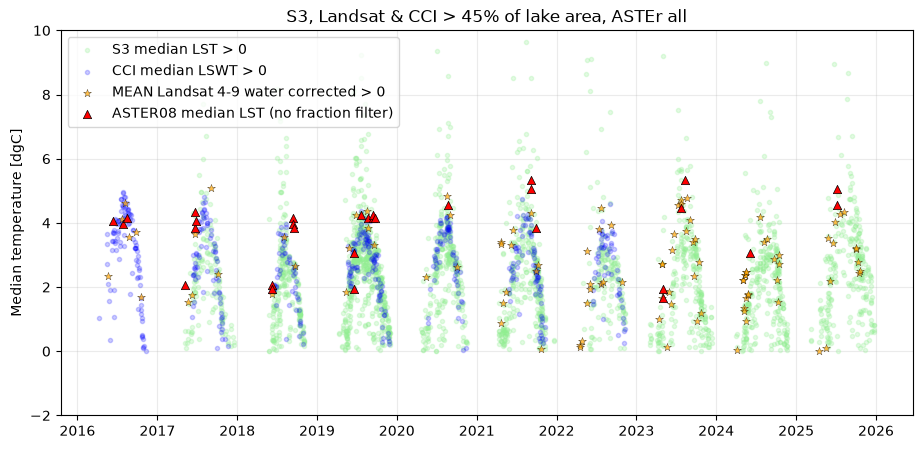

In [678]:
# start the figure
fig, ax = plt.subplots(figsize=(11, 5))

ax.set_axisbelow(True)
ax.grid(True, alpha = 0.25)

##### background with S3 and CCI #######
#S3 first
ax.scatter(
    x = combined_filter_short['datetime'], 
    y = combined_filter_short.S3_lst_median_C,
    marker = ".",
    color = 'lightgreen',
    alpha = 0.25, 
    label = "S3 median LST > 0"
)

#cci lake dataset
ax.scatter(
    x = combined_filter_short['datetime'], 
    y = combined_filter_short.CCIlst_median_C,
    marker = ".",
    color = 'blue',
    alpha = 0.2, 
    label = "CCI median LSWT > 0"
)

# Landsat data
# filter by date
ax.scatter(
    x = combined_filter_short['datetime'], 
    y = combined_filter_short.LS_ST,
    marker = "*",
    edgecolors = "black",
    linewidths=0.3,
    color = 'orange',
    alpha = 0.7, 
    label = "MEAN Landsat 4-9 water corrected > 0"
)

#### the comparison data points #########
# plot only years from 2017 onward

#ax.errorbar(
#    x=combined_filter['datetime'], 
#    y=combined_filter['CCIlst_median_C'],
#    yerr=[combined_filter.CCIlst_mean_uncertainty,combined_filter.CCIlst_mean_uncertainty],
 #   fmt='s',
#    markersize=5,
#    markerfacecolor='none',
#    markeredgecolor='darkblue',
#    markeredgewidth=0.85,
#    ecolor='darkblue',
#    elinewidth=0.5,
##    capsize=2,
#    capthick=0.5,
#    alpha=1,
#    zorder=10,
#    label="CCI median LSWT > 0, +/- 1 std"
#)

#ASTER08
ax.scatter(
    x = combined_filter_short['datetime'], 
    y = combined_filter_short['ASTER08_lst_median_C'],
    marker = "^",
    edgecolors="black",
    linewidths=0.5, 
    color = 'red',
    label = "ASTER08 median LST (no fraction filter)"
)

#S3 first
# errorbar bootstrapped CI
#ax.scatter(
#    x = joined['datetime_S3'], 
#    y = joined.S3_lst_median_C,
#    marker = "o",
#    color = 'darkgreen',
#    edgecolors="black",
#    linewidths=0.8,
#    facecolors="none",
#    label = "S3 median LST > 0 with +/- 1 std"
#)

#ax.errorbar(
#    x=combined_filter['datetime'], 
#    y=combined_filter.S3_lst_median_C,
#   yerr=[combined_filter.S3_lst_mean_uncertainty, combined_filter.S3_lst_mean_uncertainty],
#   fmt='o',
#    markersize=4,
#    markerfacecolor='none',
#    markeredgecolor='green',
##    markeredgewidth=1,
#    ecolor='darkgreen',
#    elinewidth=0.5,
#    capsize=2,
#    capthick=0.5,
#    alpha=1,
#    zorder=10,
#    label="S3 median LSWT > 0, +/- 1 std"
#)


# set ylim values
plt.ylim(-2, 10)

plt.legend()
plt.ylabel('Median temperature [dgC]')

plt.title("S3, Landsat & CCI > 45% of lake area, ASTEr all")
plt.show()

### comparsion based on time window
Idea is to match the remotely sensed lake / surface temperature from different sensors based on their aquisition time to enable best comparison.
This can only be done for:
- ASTER08
- Sentinel 3
- Landsat 4-9

In [679]:
# define a function for mathcing in a window

import pandas as pd

def time_matches(
    df1,
    df2,
    datetime_col1='datetime',
    datetime_col2='datetime',
    window_hours=3
):
    """
    Find all pairs of observations from two datasets whose
    acquisition times are within a specified time window.

    Parameters
    ----------
    df1 : pandas.DataFrame
        First dataset.
    df2 : pandas.DataFrame
        Second dataset.
    datetime_col1 : str
        Datetime column in df1.
    datetime_col2 : str
        Datetime column in df2.
    window_hours : float
        Maximum allowed time difference in hours.

    Returns
    -------
    pandas.DataFrame
        All matching pairs, including the absolute time difference.
    """

    # Make copies so the original datasets are not modified
    df1 = df1.copy()
    df2 = df2.copy()

    # Convert datetime columns to UTC
    df1[datetime_col1] = pd.to_datetime(
        df1[datetime_col1], utc=True
    )
    df2[datetime_col2] = pd.to_datetime(
        df2[datetime_col2], utc=True
    )

    # Rename datetime columns so they are distinguishable
    df1 = df1.rename(columns={datetime_col1: 'datetime_1'})
    df2 = df2.rename(columns={datetime_col2: 'datetime_2'})

    # Create all possible pairs
    pairs = df1.merge(
        df2,
        how='cross',
        suffixes=('_1', '_2')
    )

    # Calculate absolute time difference
    pairs['time_difference'] = (
        pairs['datetime_1'] - pairs['datetime_2']
    ).abs()

    # Time difference in hours
    pairs['time_difference_hours'] = (
        pairs['time_difference'].dt.total_seconds() / 3600
    )

    # Keep only pairs within specified window
    matches = pairs[
        pairs['time_difference'] <= pd.Timedelta(hours=window_hours)
    ].copy()

    # Sort by time difference
    matches = matches.sort_values(
        'time_difference'
    ).reset_index(drop=True)

    return matches

In [685]:
### make a function for plotting the matched dataframe


import numpy as np
import matplotlib.pyplot as plt


def plot_regression(
    x,
    y,
    x_label="X",
    y_label="Y",
    point_color="green",
    regression_color="blue",
    ci_color="blue",
    figsize=(4, 4),
    n_bootstrap=5000,
    seed=42, 
    ylim = None,
    xlim = None
):
    """
    Plot a regression between x and y with:
    - scatter points
    - 1:1 line
    - linear regression
    - bootstrapped 95% confidence interval
    - R²
    - slope
    - intercept
    - RMSE
    - number of observations

    Parameters
    ----------
    x : array-like
        X values.
    y : array-like
        Y values.
    x_label : str
        Label for x-axis.
    y_label : str
        Label for y-axis.
    point_color : str
        Color of scatter points.
    regression_color : str
        Color of regression line.
    ci_color : str
        Color of confidence interval.
    figsize : tuple
        Figure size.
    n_bootstrap : int
        Number of bootstrap iterations.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    fig, ax, stats
        Matplotlib figure, axes, and dictionary containing
        regression statistics.
    """
    # ---------------------------------------------------------
    # Convert to numpy arrays and remove NaN/infinite values
    # ---------------------------------------------------------

    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    # Check that enough data remain
    if len(x) < 2:
        raise ValueError(
            "Not enough valid data points for regression."
        )

    # ---------------------------------------------------------
    # Linear regression
    # ---------------------------------------------------------

    m, b = np.polyfit(x, y, 1)

    # Predicted values
    y_pred = m * x + b

    # R²
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    # RMSE
    rmse = np.sqrt(
        np.mean((y - y_pred) ** 2)
    )

    # ---------------------------------------------------------
    # Bootstrap 95% confidence interval
    # ---------------------------------------------------------

    rng = np.random.default_rng(seed)

    x_line = np.linspace(
        x.min(),
        x.max(),
        200
    )

    bootstrap_predictions = np.empty(
        (n_bootstrap, len(x_line))
    )

    for i in range(n_bootstrap):

        # Resample observations with replacement
        indices = rng.integers(
            0,
            len(x),
            size=len(x)
        )

        x_boot = x[indices]
        y_boot = y[indices]

        # Regression on bootstrap sample
        m_boot, b_boot = np.polyfit(
            x_boot,
            y_boot,
            1
        )

        # Prediction
        bootstrap_predictions[i] = (
            m_boot * x_line + b_boot
        )

    # 95% CI
    lower_ci = np.percentile(
        bootstrap_predictions,
        2.5,
        axis=0
    )

    upper_ci = np.percentile(
        bootstrap_predictions,
        97.5,
        axis=0
    )

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=figsize
    )

    # Scatter
    ax.scatter(
        x,
        y,
        alpha=0.5,
        color=point_color,
        edgecolor="none"
    )

    # ---------------------------------------------------------
    # 1:1 line
    # ---------------------------------------------------------

    min_val = min(
        x.min(),
        y.min()
    )

    max_val = max(
        x.max(),
        y.max()
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="1:1 line"
    )

    # ---------------------------------------------------------
    # Regression line
    # ---------------------------------------------------------

    ax.plot(
        x_line,
        m * x_line + b,
        color=regression_color,
        linewidth=2,
        label="Regression"
    )

    # ---------------------------------------------------------
    # Confidence interval
    # ---------------------------------------------------------

    ax.fill_between(
        x_line,
        lower_ci,
        upper_ci,
        color=ci_color,
        alpha=0.2,
        label="95% CI"
    )

    # ---------------------------------------------------------
    # Labels
    # ---------------------------------------------------------

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if xlim is not None:
        ax.set_xlim(xlim)
    else:
        ax.set_xlim(min_val, max_val)

    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(min_val, max_val)

    # Grid
    ax.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    # ---------------------------------------------------------
    # Statistics box
    # ---------------------------------------------------------

    stats_text = (
        f"$R^2$ = {r2:.2f}\n"
        f"Slope = {m:.2f}\n"
        f"Intercept = {b:.2f}\n"
        f"RMSE = {rmse:.2f} °C\n"
        f"n = {len(x)}"
    )

    ax.text(
        0.05,
        0.95,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

    ax.legend(
        loc="lower right"
    )

    plt.tight_layout()

    # ---------------------------------------------------------
    # Return statistics as well
    # ---------------------------------------------------------

    stats = {
        "slope": m,
        "intercept": b,
        "r2": r2,
        "rmse": rmse,
        "n": len(x)
    }

    return fig, ax, stats

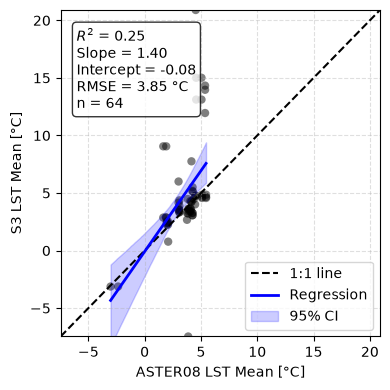

   ASTER08_Unnamed: 0                                       ASTER08_file                datetime_1  ASTER08_n_valid_pixels  ASTER08_lst_mean_C  ASTER08_lst_median_C  ASTER08_lst_std  \
0                  34  C:\Users\Lenovo\Documents\GEUS_internship\LWST... 2012-07-18 14:49:08+00:00                    5333            3.899065              4.650024         2.628728   
1                   4  C:\Users\Lenovo\Documents\GEUS_internship\LWST... 2003-04-21 14:49:39+00:00                    5341           -0.539522             -0.549988         0.635083   
2                   2  C:\Users\Lenovo\Documents\GEUS_internship\LWST... 2003-04-12 14:55:53+00:00                     124           -7.810472             -7.849976         0.347065   
3                   3  C:\Users\Lenovo\Documents\GEUS_internship\LWST... 2003-04-12 14:56:02+00:00                    5348           -8.126483             -8.149994         0.462974   
4                  47  C:\Users\Lenovo\Documents\GEUS_internship\LWST... 20

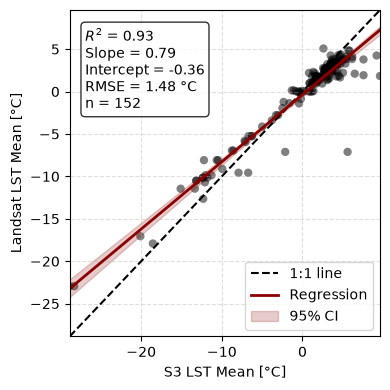

In [686]:
# apply the two functions: 

############ ASTER - S3 #######################
ASTER_S3_matches = time_matches(
    ASTER08,
    S3,
    datetime_col1='datetime',
    datetime_col2='datetime',
    window_hours=3
)

fig, ax, stats = plot_regression(
    x=ASTER_S3_matches['ASTER08_lst_mean_C'],
    y=ASTER_S3_matches['S3_lst_mean_C'],
    x_label="ASTER08 LST Mean [°C]",
    y_label="S3 LST Mean [°C]",
    point_color="black",
    regression_color="blue",
    ci_color="blue", 
    xlim = None, 
    ylim = None
)


plt.show()

############## ASTEr - Landsat ####################
ASTER_LS_matches = time_matches(
    ASTER08,
    LS,
    datetime_col1='datetime',
    datetime_col2='datetime',
    window_hours=3
)

print(ASTER_LS_matches)

ASTER_LS_matches = ASTER_LS_matches[
    (
        ASTER_LS_matches['LS_frac_from_max_pixel_count'].isna() |
        (ASTER_LS_matches['LS_frac_from_max_pixel_count'] > 0.45)
    )
    &
    (
        ASTER_LS_matches['ASTER08_frac_from_max_pixel_count'].isna() |
        (ASTER_LS_matches['ASTER08_frac_from_max_pixel_count'] > 0.45)
    )
]

print(ASTER_LS_matches)

#fig, ax, stats = plot_regression(
#    x=ASTER_LS_matches['ASTER08_lst_mean_C'],
##    y=ASTER_LS_matches['LS_ST'],
#    x_label="ASTER08 LST Mean [°C]",
#    y_label="Landsat LST Mean [°C]",
#    point_color="black",
#    regression_color="green",
#    ci_color="green"
#)

#plt.show()

############## S3 - Landsat ########################
S3_LS_matches = time_matches(
    S3,
    LS,
    datetime_col1='datetime',
    datetime_col2='datetime',
    window_hours=3
)

S3_LS_matches = S3_LS_matches[
    (
        S3_LS_matches['S3_frac_from_max_pixel_count'].isna() |
        (S3_LS_matches['S3_frac_from_max_pixel_count'] > 0.45)
    )
    &
    (
        S3_LS_matches['LS_frac_from_max_pixel_count'].isna() |
        (S3_LS_matches['LS_frac_from_max_pixel_count'] > 0.45)
    )
]

fig, ax, stats = plot_regression(
    x=S3_LS_matches['S3_lst_mean_C'],
    y=S3_LS_matches['LS_ST'],
    x_label="S3 LST Mean [°C]",
    y_label="Landsat LST Mean [°C]",
    point_color="black",
    regression_color="darkred",
    ci_color="darkred"
)

plt.show()

### CCI dataset is daily temporal resolution
Draw the CCI dataset in. This is daily resolution (time set to 12 midday).
Due to the different temporal resolution (not evenly spaced aqisition time for S3 for example(there are often images quite close to each other), although relatively even for Landsat), I cannot use the 12h window approach: Sometimes there would be many matches for S3 images, and for other eg images that are more closely together this would result in matching the same s3 image to several Landsat scenes. This would create temporal autocorrelation, which violates the assumption of non-independent errors of the linear model. 

To exclude this effect, I take the daily mean of all data sources to bring it to the same resolution as CCI lake dataset and the match for having daily values. 
However, this creates the difficulty that in some occasions I coud be comparing day and night values...

In [683]:
# use the previously created data frame (matched by datetime) ## combined
combined_filter["date"] = combined_filter["datetime"].dt.date

# set upper bound for S3 temperature --> derived from previous plots: most values above 6 dgC have very low number of pixels, and are therefore likely wrong
combined_filter = combined_filter[(combined_filter.S3_lst_mean_C <6) | (combined_filter.S3_lst_mean_C.isna())]

# Average sales and revenue, but total the volume
daily_summary = combined_filter.groupby('date', as_index=False).agg({
    'ASTER08_lst_mean_C': 'mean',
    'S3_lst_mean_C': 'mean',
    'CCIlst_mean_C': 'mean', 
    'LS_ST': 'mean'
})

daily_summary

# filter for some values: a type of quality control for S3
# implement upper bounds for S3: below 6dg, or NAN in the column on 

,date,ASTER08_lst_mean_C,S3_lst_mean_C,CCIlst_mean_C,LS_ST
0,1987-09-15,NaN,NaN,NaN,2.698184
1,1992-06-10,NaN,NaN,NaN,1.522894
2,1992-07-03,NaN,NaN,NaN,0.450392
3,1992-07-10,NaN,NaN,NaN,0.490717
4,1992-07-12,NaN,NaN,NaN,2.384987
...,...,...,...,...,...
1379,2026-06-15,NaN,NaN,NaN,3.750396
1380,2026-07-08,NaN,NaN,NaN,3.815786
1381,2026-08-09,NaN,NaN,NaN,3.903073
1382,2026-08-10,NaN,NaN,NaN,4.276701


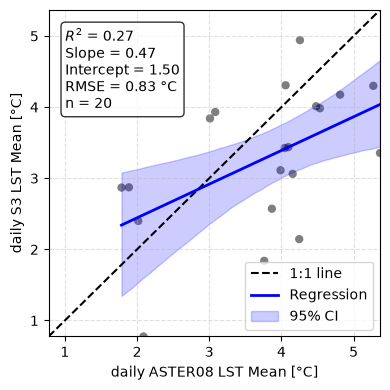

<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWarning: Polyfit may be poorly conditioned
<positron-console-cell-687>:130: RankWar

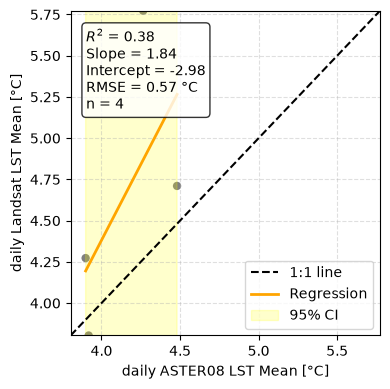

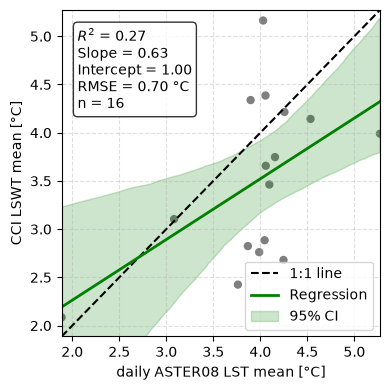

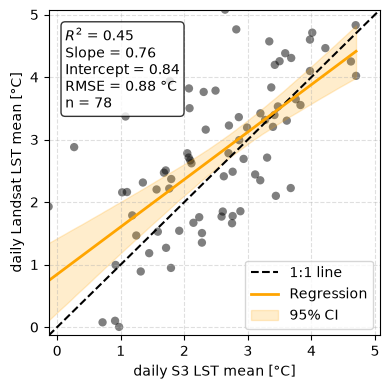

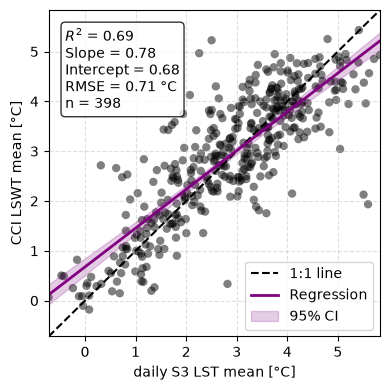

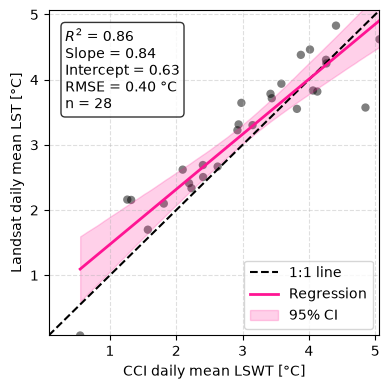

In [687]:
# apply the two functions: 

############ ASTER - S3 #######################
fig, ax, stats = plot_regression(
    x=daily_summary['ASTER08_lst_mean_C'],
    y=daily_summary['S3_lst_mean_C'],
    x_label="daily ASTER08 LST Mean [°C]",
    y_label="daily S3 LST Mean [°C]",
    point_color="black",
    regression_color="blue",
    ci_color="blue"
)

plt.show()

############## ASTEr - Landsat ####################
fig, ax, stats = plot_regression(
    x=daily_summary['ASTER08_lst_mean_C'],
    y=daily_summary['LS_ST'],
    x_label="daily ASTER08 LST Mean [°C]",
    y_label="daily Landsat LST Mean [°C]",
    point_color="black",
    regression_color="orange",
    ci_color="yellow"
)

plt.show()

############## ASTER - CCI ####################
fig, ax, stats = plot_regression(
    x=daily_summary['ASTER08_lst_mean_C'],
    y=daily_summary['CCIlst_mean_C'],
    x_label="daily ASTER08 LST mean [°C]",
    y_label="CCI LSWT mean [°C]",
    point_color="black",
    regression_color="green",
    ci_color="green"
)

plt.show()



############## S3 - Landsat ########################

fig, ax, stats = plot_regression(
    x=daily_summary['S3_lst_mean_C'],
    y=daily_summary['LS_ST'],
    x_label="daily S3 LST mean [°C]",
    y_label="daily Landsat LST mean [°C]",
    point_color="black",
    regression_color="orange",
    ci_color="orange"
)

plt.show()

############# S3 vs CCI ############################
fig, ax, stats = plot_regression(
    x=daily_summary['S3_lst_mean_C'],
    y=daily_summary['CCIlst_mean_C'],
    x_label="daily S3 LST mean [°C]",
    y_label="CCI LSWT mean [°C]",
    point_color="black",
    regression_color="purple",
    ci_color="purple"
)

plt.show()

############# S3 vs CCI ############################
fig, ax, stats = plot_regression(
    x=daily_summary['CCIlst_mean_C'],
    y=daily_summary['LS_ST'],
    x_label="CCI daily mean LSWT [°C]",
    y_label="Landsat daily mean LST [°C]",
    point_color="black",
    regression_color="deeppink",
    ci_color="deeppink"
)

plt.show()

### do a comparison of the august temperature 

in the IML data set Panny only used the August lake temperatures since she could be sure that by then the lake would not be ice-covered anymore
Therefore, I here compare the mean august temperatures for all the years (seperately) from the different sensors:
I use boxplots for this.

Note, that I filter ehere for the following:
- only august temperatures, in order to exclude the possobility that there could be somehow ice on the lake
- look at years from 2012 onward, since before this there is only few landsat (and one ASTEr) scene that could be used
- I have set a maximum temperature bound in the raw data to 7dg celsius (since based on previous inspections of the data all higehr temperatures were based on really few data points and therefore considered unstable/invalid)

### The right tool to look for a trend would be a linear mixed effect model 
The data is grouped / heirarchial due to the different sensors measuring the same. If I had different lakes, this would be another level within the data.

The slope would be fixed (since one would assume that the trend is the same for every sensor...), however with a random intercept. 

# do a scatter plot 



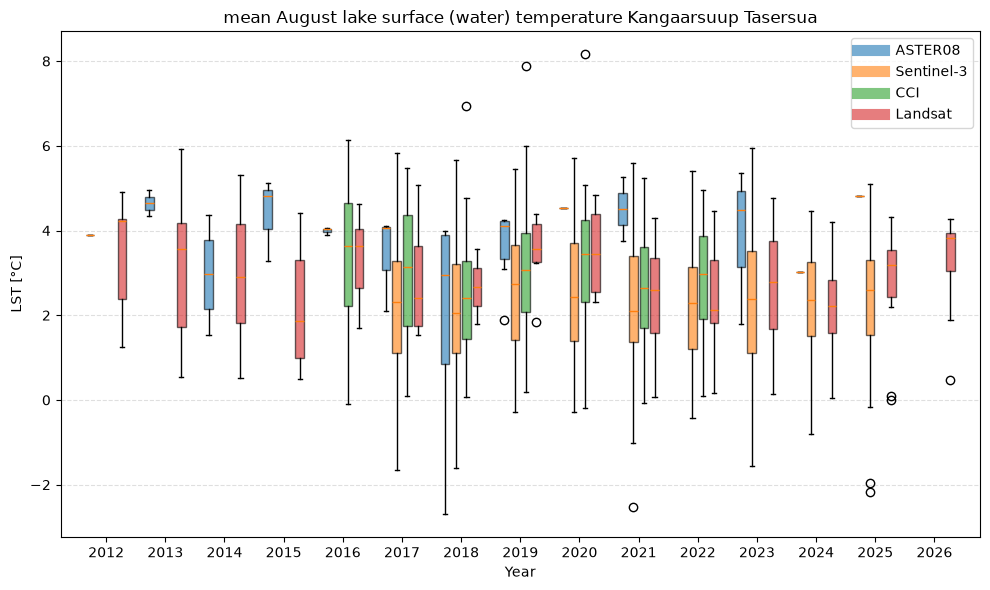

In [489]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure date is datetime
daily_summary['date'] = pd.to_datetime(
    daily_summary['date']
)

# Keep August only
daily_aug = daily_summary[
    (daily_summary['date'].dt.month == 8) | (daily_summary['date'].dt.month == 8)
].copy()

# filter for years from 2012 onward
daily_aug = daily_summary[
    (daily_summary['date'].dt.year > 2011)].copy()

# Extract year
daily_aug['year'] = daily_aug['date'].dt.year

# Sensors
sensor_columns = [
    'ASTER08_lst_mean_C',
    'S3_lst_mean_C',
    'CCIlst_mean_C',
    'LS_ST'
]

sensor_labels = [
    'ASTER08',
    'Sentinel-3',
    'CCI',
    'Landsat'
]

# Colors for each sensor
sensor_colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red'
]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

years = sorted(
    daily_aug['year'].dropna().unique()
)

width = 0.18

# Position offsets so boxes sit next to each other
offsets = (
    np.arange(len(sensor_columns))
    - (len(sensor_columns) - 1) / 2
)

# ---------------------------------------------------------
# Create boxplots
# ---------------------------------------------------------

for i, (sensor, label, color) in enumerate(
    zip(sensor_columns, sensor_labels, sensor_colors)
):

    # Data for each year
    data = [
        daily_aug.loc[
            daily_aug['year'] == year,
            sensor
        ].dropna()
        for year in years
    ]

    # Position for each box
    positions = (
        np.array(years)
        + offsets[i] * width
    )

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True
    )

    # Color the boxes
    for box in bp['boxes']:
        box.set_facecolor(color)
        box.set_alpha(0.6)

    # Add invisible point for legend
    ax.plot(
        [],
        [],
        color=color,
        linewidth=8,
        alpha=0.6,
        label=label
    )

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

ax.set_xlabel("Year")
ax.set_ylabel("LST [°C]")

ax.set_xticks(years)
ax.set_xticklabels(years)

ax.set_title(
    "mean August lake surface (water) temperature Kangaarsuup Tasersua"
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

ax.legend()

plt.tight_layout()
plt.show()

# What is here to do?
- check the underlying data: Why is there some points double (darker due to the alpha value set here) - this is because there are several values / very close and similar scenes in the 3h window which match with just one scene of the other sensor I am comparing with in the scatter plot (temporal autocorrelation)
- add bootstrapped 95% CI (since there is a small data size --> CI needs to be bootstrapped due to small sample sizes)
- **add errrorbars/uncertainty around points**
- **fit model with and without data for 2022 for CCI vs S3 --> 2022 the spead in S3 increased a lot...**


#